## Passo 1 — Importar as bibliotecas

Importamos as bibliotecas necessárias para o projeto:

- `pandas` — manipulação e organização dos dados
- `StandardScaler` — normalização das métricas
- `KMeans` — algoritmo de clusterização
- `matplotlib` — visualização dos resultados

In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## Passo 2 — Carregar e filtrar os dados

Carregamos o arquivo Excel com os dados históricos das partidas
e filtramos apenas as linhas do segmento `Whole Session`.

O `Whole Session` representa os dados completos de cada partida,
sem divisão por tempo — ideal para classificar o desempenho
geral do atleta em cada jogo.

O resultado esperado é:
- Número de linhas correspondente aos jogos completos registrados
- 26 atletas únicos no elenco

In [15]:
filePath = "../data/players.xlsx"

df = pd.read_excel(filePath)

ws = df[df['Segment Name'] == 'Whole Session'].copy()

print(ws.shape)
print(ws['Athlete ID'].nunique())

(708, 34)
26


### Passo 2.1 — Filtrar partidas com dados insuficientes

Identificamos 42 partidas com métricas zeradas ou próximas
de zero, provavelmente registros corrompidos ou atletas
que não chegaram a jogar efetivamente.

Filtramos partidas com Distance menor que 2000m, valor
abaixo do mínimo esperado para qualquer participação
real em uma partida de futebol.

In [16]:
ws = ws[ws['Distance (m)'] > 2000]

print(ws.shape)
print(ws['Distance (m)'].describe())

(609, 34)
count      609.000000
mean      8201.300493
std       2949.928015
min       2014.000000
25%       5672.000000
50%       8937.000000
75%      10497.000000
max      15561.000000
Name: Distance (m), dtype: float64


## Passo 3 — Selecionar as métricas e remover valores faltando

Selecionamos apenas as colunas relevantes para o perfil
físico do atleta, descartando colunas administrativas
como nome, posição e data.

Diferente da abordagem anterior, não fazemos agregação —
cada linha continua representando um jogo de um atleta.

O `dropna()` remove partidas com alguma métrica faltando,
garantindo que o modelo receba dados completos.

O resultado esperado é uma tabela com aproximadamente
700 linhas e 8 colunas.

In [17]:
metrics = [
    'Distance (m)',
    'High Intensity Running (m)',
    'Sprint Distance (m)',
    'Top Speed (kph)',
    'Accelerations',
    'Decelerations',
    'Metres per Minute (m)'
]

# 'Session Load' foi removido pq tem muitos poucos dados dele, se eu levar ele em conta, há uma perca de 40% nos dados totais

match_df = ws[metrics].dropna()

print(match_df.shape)
print(match_df.head())

(609, 7)
    Distance (m)  High Intensity Running (m)  Sprint Distance (m)  \
0         8348.0                       554.0                134.0   
4         7853.0                       412.0                 43.0   
8         6395.0                       438.0                137.0   
12        9243.0                       509.0                 70.0   
16        8174.0                       418.0                148.0   

    Top Speed (kph)  Accelerations  Decelerations  Metres per Minute (m)  
0              30.2           81.0           78.0                   56.0  
4              26.7           60.0           48.0                   52.0  
8              31.1           61.0           46.0                   43.0  
12             27.2           84.0           79.0                   62.0  
16             28.9           64.0           55.0                   54.0  


## Passo 4 — Normalizar os dados

Antes de rodar o K-Means, precisamos normalizar as métricas
para que todas fiquem na mesma escala.

Sem normalização, métricas com valores maiores como
Distance (m) dominariam o agrupamento injustamente
em relação a métricas menores como Top Speed (kph).

O StandardScaler transforma cada coluna para ter
média 0 e desvio padrão 1.

O resultado são valores entre aproximadamente -2 e +2,
onde 0 representa a média, positivo acima da média
e negativo abaixo da média.

In [18]:
scaler = StandardScaler()
X = scaler.fit_transform(match_df)

print(X[:5])

[[ 0.04977074  1.4941685   1.10509975  1.05535329  0.82899865  0.43356533
  -0.76356633]
 [-0.1181679   0.57282639 -0.52575592 -0.86040684 -0.02960709 -0.71560609
  -0.90451106]
 [-0.61282354  0.74152283  1.15886422  1.54797733  0.01127889 -0.79221752
  -1.2216367 ]
 [ 0.35341738  1.20219389 -0.04187567 -0.58672682  0.95165662  0.47187105
  -0.55214924]
 [-0.00926224  0.61175634  1.35600062  0.34378525  0.13393686 -0.44746609
  -0.8340387 ]]


## Passo 5 — Rodar o K-Means

Com os dados normalizados, treinamos o modelo K-Means com K=4,
definido pelo Método do Cotovelo.

Agora cada partida de cada atleta recebe um label de 0 a 3,
representando o tipo de desempenho apresentado naquele jogo.

Parâmetros utilizados:
- `n_clusters=4` — número de grupos definido pelo cotovelo
- `random_state=42` — garante reprodutibilidade dos resultados
- `n_init=10` — roda 10 vezes e escolhe o melhor agrupamento

In [19]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
km.fit(X)

labels = km.labels_

print(labels)
print(f"Total de partidas classificadas: {len(labels)}")

[0 2 2 1 2 0 2 1 2 1 1 0 1 0 0 0 1 1 0 1 1 1 3 2 0 0 1 1 1 0 0 1 1 1 1 0 1
 1 1 1 2 0 0 3 0 0 0 2 1 1 0 1 2 3 1 0 0 3 1 1 0 0 3 0 0 2 1 2 1 1 0 3 2 1
 0 0 3 1 0 1 0 1 1 1 2 3 2 0 1 3 1 0 1 1 0 2 1 1 3 2 3 3 0 0 1 3 1 0 0 0 0
 1 1 1 0 1 1 0 1 1 2 3 0 1 1 3 0 2 0 0 0 1 1 1 2 2 3 3 3 0 0 0 2 3 1 0 0 2
 3 0 3 0 3 0 0 1 2 2 0 2 0 3 3 1 1 2 0 0 1 0 3 1 3 1 2 1 2 0 2 2 1 2 1 1 2
 0 1 3 2 0 0 1 0 1 0 0 2 1 2 3 2 2 3 3 1 1 1 3 1 2 1 3 0 3 0 1 0 0 1 0 3 1
 2 1 1 0 1 0 2 2 2 3 2 3 1 1 0 1 3 1 1 2 1 3 2 0 1 3 1 1 1 2 2 1 0 3 2 1 2
 1 1 0 3 1 1 0 1 2 3 1 3 2 1 3 1 3 2 1 2 1 2 2 1 0 3 1 2 1 2 2 3 3 0 1 1 2
 3 1 2 1 2 0 3 3 1 1 3 3 2 1 3 1 2 1 0 0 1 2 3 2 2 1 1 2 3 0 3 3 1 1 2 1 2
 3 0 3 1 2 2 3 3 2 0 1 1 2 1 2 1 2 2 3 1 1 2 3 0 3 1 1 3 1 2 1 3 3 2 1 1 0
 1 3 1 0 3 1 1 1 3 1 2 3 2 1 2 3 0 0 3 2 2 1 2 1 1 1 0 3 0 3 1 2 3 1 1 3 2
 1 3 2 2 3 1 1 2 2 1 3 1 0 1 1 2 3 1 3 3 1 1 1 3 1 3 0 3 1 3 0 0 2 1 2 2 0
 2 2 0 1 2 2 0 3 3 1 0 3 1 1 0 0 1 1 3 1 1 1 1 1 3 2 2 1 3 2 2 1 1 1 1 1 2
 0 1 0 0 1 3 3 3 3 2 1 0 

## Passo 6 — Adicionar os clusters ao dataframe

Adicionamos o label de cada cluster de volta ao dataframe,
associando cada partida ao seu tipo de desempenho.

O `value_counts()` mostra a distribuição das partidas
entre os 4 clusters — quantas partidas foram classificadas
em cada tipo de desempenho.

In [20]:
match_df = match_df.copy()
match_df['Cluster'] = labels

print(match_df['Cluster'].value_counts())

Cluster
1    238
2    128
0    127
3    116
Name: count, dtype: int64


## Passo 7 — Analisar o perfil de cada cluster

Calculamos a média de cada métrica por cluster,
revelando o centróide de cada grupo em valores reais.

Essa é a etapa de interpretação — aqui conseguimos
entender o que cada cluster representa fisicamente
e propor nomes para cada perfil de desempenho.

In [21]:
print(match_df.groupby('Cluster')[metrics].mean().round(2))

         Distance (m)  High Intensity Running (m)  Sprint Distance (m)  \
Cluster                                                                  
0            10510.89                      515.17               146.35   
1            10098.03                      337.63                54.84   
2             6298.62                      269.05                74.67   
3             3880.63                      145.87                24.63   

         Top Speed (kph)  Accelerations  Decelerations  Metres per Minute (m)  
Cluster                                                                        
0                  29.93          86.56          93.75                  97.74  
1                  27.90          69.95          76.61                  96.45  
2                  29.03          46.69          51.49                  59.22  
3                  26.39          28.99          33.45                  37.52  


### 7.1 — Visualização de dispersão 2D com PCA

Como os dados têm 7 dimensões, usamos PCA para reduzi-los
a 2 componentes principais, preservando o máximo de
variância possível.

Cada ponto representa uma partida de um atleta,
e cada cor representa um cluster de desempenho.

Variância explicada: 83.06%


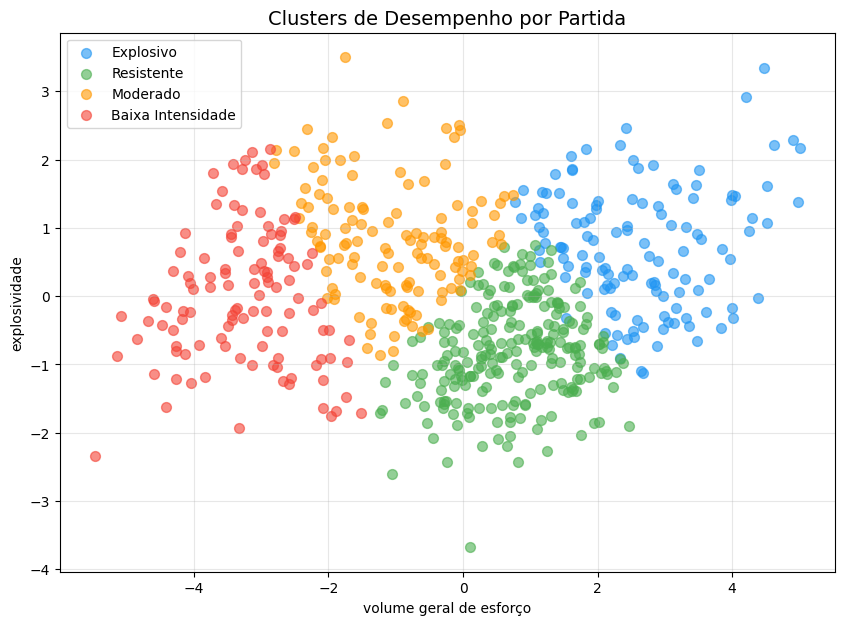

In [23]:
from sklearn.decomposition import PCA

# Reduzir para 2 dimensões
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

print(f"Variância explicada: {pca.explained_variance_ratio_.sum():.2%}")

# Plotar
plt.figure(figsize=(10, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
cluster_names = ['Explosivo', 'Resistente', 'Moderado', 'Baixa Intensidade']

for cluster in range(4):
    mask = labels == cluster
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[cluster],
                label=cluster_names[cluster],
                alpha=0.6, s=50)

plt.title('Clusters de Desempenho por Partida', fontsize=14)
plt.xlabel('volume geral de esforço')
plt.ylabel('explosividade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Passo 8 — Conectar os clusters ao atleta

Adicionamos as colunas de identificação de volta ao dataframe,
associando cada partida clusterizada ao seu atleta,
data e posição.

Isso nos permite analisar a evolução do desempenho
de cada jogador ao longo da temporada, identificando
padrões e mudanças de perfil entre partidas.

In [24]:
# Pegar as colunas de identificação do ws filtrado
match_df['Athlete ID'] = ws['Athlete ID'].values
match_df['Start Date'] = ws['Start Date'].values
match_df['Athlete Position'] = ws['Athlete Position'].values

print(match_df[['Athlete ID', 'Start Date', 'Athlete Position', 'Cluster']].head(10))

    Athlete ID Start Date             Athlete Position  Cluster
0   2240331969 2025-01-31  Centre Attacking Midfielder        0
4   1588115292 2025-01-31                  Centre Back        2
8   2269191174 2025-01-31                  Centre Back        2
12  4043691916 2025-01-31  Centre Attacking Midfielder        1
16  1072007304 2025-01-31                  Centre Back        2
20  1072007304 2025-01-31              Right Wing Back        0
24  1020172514 2025-01-31            Centre Midfielder        2
28  1010711410 2025-01-31               Left Wing Back        1
32  2432114111 2025-01-31            Centre Midfielder        2
36  2565601833 2025-01-31  Centre Attacking Midfielder        1


## Passo 9 — Distribuição de clusters por atleta

Agrupamos as partidas por atleta e cluster, criando
uma tabela que mostra quantas partidas de cada tipo
cada jogador teve ao longo da temporada.

Essa visão permite identificar o perfil predominante
de cada atleta e detectar mudanças de comportamento
ao longo do tempo.

In [25]:
athlete_clusters = match_df.groupby(['Athlete ID', 'Cluster']).size().unstack(fill_value=0)
athlete_clusters.columns = ['Explosivo', 'Resistente', 'Moderado', 'Baixa Intensidade']
athlete_clusters['Total Partidas'] = athlete_clusters.sum(axis=1)

print(athlete_clusters)

            Explosivo  Resistente  Moderado  Baixa Intensidade  Total Partidas
Athlete ID                                                                    
75075071            3          10         8                  5              26
436974456           0           5         2                  1               8
679795059           6          11         8                  9              34
1010711410          1           5         4                  3              13
1020172514          6          12         5                  5              28
1047619934          7          11         7                  4              29
1072007304          8          13        11                  4              36
1426597544          2           0         1                  2               5
1588115292          4          10         6                 11              31
1620716011         14          17         4                  5              40
1647675003          4           5         3         

## Passo 10 — Perfil predominante por atleta

Identificamos o cluster mais frequente de cada atleta,
definindo seu perfil predominante ao longo da temporada.

Esse é o resultado final do modelo de clusterização —
cada atleta recebe um perfil baseado no seu histórico
real de partidas.

In [27]:
cols = ['Explosivo', 'Resistente', 'Moderado', 'Baixa Intensidade']
percentuals = athlete_clusters[cols].div(athlete_clusters['Total Partidas'], axis=0) * 100
percentuals = percentuals.round(1)
percentuals['Total Partidas'] = athlete_clusters['Total Partidas']

print(percentuals)

            Explosivo  Resistente  Moderado  Baixa Intensidade  Total Partidas
Athlete ID                                                                    
75075071         11.5        38.5      30.8               19.2              26
436974456         0.0        62.5      25.0               12.5               8
679795059        17.6        32.4      23.5               26.5              34
1010711410        7.7        38.5      30.8               23.1              13
1020172514       21.4        42.9      17.9               17.9              28
1047619934       24.1        37.9      24.1               13.8              29
1072007304       22.2        36.1      30.6               11.1              36
1426597544       40.0         0.0      20.0               40.0               5
1588115292       12.9        32.3      19.4               35.5              31
1620716011       35.0        42.5      10.0               12.5              40
1647675003       25.0        31.2      18.8         